In [2]:
from google.colab import files

uploaded = files.upload()

# Get the name of the uploaded file (assuming you upload one file)
# Replace 'your_excel_file.xlsx' with the exact name if you know it.
xlsx_filename = list(uploaded.keys())[0]

print(f"Uploaded file: {xlsx_filename}")

Saving Anemia_Dataset.SHAIKAT.xlsx to Anemia_Dataset.SHAIKAT.xlsx
Uploaded file: Anemia_Dataset.SHAIKAT.xlsx


In [3]:
import pandas as pd

# Load the dataset
file_path = "Anemia_Dataset.SHAIKAT.xlsx"   # change path if needed
df = pd.read_excel(file_path)

# 1. Check number of rows and columns
print("Dataset shape (rows, columns):")
print(df.shape)

# 2. Check column names
print("\nColumn names:")
print(df.columns.tolist())

# 3. Check data types
print("\nData types:")
print(df.dtypes)

# 4. Show first 5 rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# 5. Define features and target column
features = ["Gender", "Age", "HGB(Hemoglobin)", "RBC", "PCV/HCT", "MCV", "MCH", "MCHC"]
target = "Decision_Class"

print("\nFeature columns:")
print(features)

print("\nTarget column:")
print(target)

# 6. Optional check: confirm these columns exist in dataset
print("\nChecking if all required columns exist:")
for col in features + [target]:
    if col in df.columns:
        print(f"{col} -> Found")
    else:
        print(f"{col} -> Not Found")

Dataset shape (rows, columns):
(1004, 9)

Column names:
['Gender ', 'Age ', 'HGB(Hemoglobin)', 'RBC', 'PCV/HCT', 'MCV', 'MCH', 'MCHC', 'Decision_Class']

Data types:
Gender              object
Age                float64
HGB(Hemoglobin)    float64
RBC                float64
PCV/HCT            float64
MCV                float64
MCH                float64
MCHC               float64
Decision_Class       int64
dtype: object

First 5 rows of the dataset:
  Gender   Age   HGB(Hemoglobin)   RBC  PCV/HCT   MCV   MCH  MCHC  \
0       F  45.0             12.1  4.64     37.9  81.7  26.1  31.9   
1       M  70.0             13.4  5.32     45.8  86.1  25.2  29.3   
2       F  80.0              8.3  3.04     25.2  82.9  27.3  32.9   
3       F  30.0             11.1  3.98     33.5  84.2  27.9  33.1   
4       F  46.0             15.5  5.50     45.7  83.1  28.2  33.9   

   Decision_Class  
0               0  
1               0  
2               1  
3               0  
4               0  

Feature col

In [5]:
import pandas as pd
import numpy as np

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# -----------------------------
# Step 2: Inspect data quality
# -----------------------------

# 1. Check missing values
print("Missing values in each column")
print(df.isnull().sum())

# 2. Check duplicate rows
print("\nNumber of duplicate rows")
print(df.duplicated().sum())

# Show duplicate rows if you want
duplicate_rows = df[df.duplicated()]
print("\nFirst 5 duplicate rows")
print(duplicate_rows.head())

# 3. Check inconsistent Gender values
print("\nUnique values in Gender column")
print(df["Gender"].unique())

print("\nGender value counts")
print(df["Gender"].value_counts(dropna=False))

# 4. Check unusual / outlier values in numeric columns
numeric_cols = ["Age", "HGB(Hemoglobin)", "RBC", "PCV/HCT", "MCV", "MCH", "MCHC"]

print("\nSummary statistics for numeric columns")
print(df[numeric_cols].describe())

# IQR-based outlier check
print("\nOutlier count in each numeric column using IQR method")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

# Optional: show actual outlier rows for one column
example_col = "MCHC"
Q1 = df[example_col].quantile(0.25)
Q3 = df[example_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mchc_outliers = df[(df[example_col] < lower_bound) | (df[example_col] > upper_bound)]

print(f"\nOutlier rows in {example_col}")
print(mchc_outliers)

# 5. Check class balance in target column
print("\nClass distribution in Decision_Class")
print(df["Decision_Class"].value_counts())

print("\nClass percentage in Decision_Class")
print(df["Decision_Class"].value_counts(normalize=True) * 100)

Missing values in each column
Gender             0
Age                0
HGB(Hemoglobin)    0
RBC                0
PCV/HCT            1
MCV                0
MCH                0
MCHC               0
Decision_Class     0
dtype: int64

Number of duplicate rows
27

First 5 duplicate rows
    Gender   Age  HGB(Hemoglobin)   RBC  PCV/HCT   MCV   MCH  MCHC  \
589      M   9.0              8.4  5.34     28.7  53.7  15.8  29.4   
590      M  14.0              7.9  4.31     27.0  62.6  18.4  29.5   
593      F   1.0             10.1  4.27     31.6  74.0  23.7  32.0   
800      F  49.0              9.1  3.43     27.5  80.2  26.5  33.1   
802      F  13.0              8.8  3.84     27.7  72.1  22.9  31.8   

     Decision_Class  
589               1  
590               1  
593               1  
800               1  
802               1  

Unique values in Gender column
['F' 'M' ' F']

Gender value counts
Gender
F     531
M     471
 F      2
Name: count, dtype: int64

Summary statistics for numeric

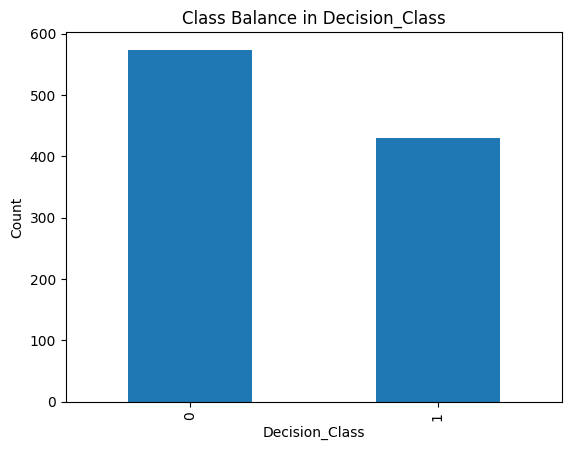

In [7]:
import matplotlib.pyplot as plt

df["Decision_Class"].value_counts().plot(kind="bar")
plt.title("Class Balance in Decision_Class")
plt.xlabel("Decision_Class")
plt.ylabel("Count")
plt.show()

Unique Gender values BEFORE cleaning:
['F' 'M' ' F']

Unique Gender values AFTER cleaning:
['Female' 'Male']

Gender value counts AFTER cleaning:
Gender
Female    533
Male      471
Name: count, dtype: int64

Rows with unexpected Gender values:
Empty DataFrame
Columns: [Gender, Age, HGB(Hemoglobin), RBC, PCV/HCT, MCV, MCH, MCHC, Decision_Class]
Index: []

Missing values BEFORE imputation:
Gender             0
Age                0
HGB(Hemoglobin)    0
RBC                0
PCV/HCT            1
MCV                0
MCH                0
MCHC               0
Decision_Class     0
dtype: int64

Median used for PCV/HCT imputation: 35.5

Missing values AFTER imputation:
Gender             0
Age                0
HGB(Hemoglobin)    0
RBC                0
PCV/HCT            0
MCV                0
MCH                0
MCHC               0
Decision_Class     0
dtype: int64

Shape BEFORE removing duplicates: (1004, 9)
Duplicate rows BEFORE removal: 27

Shape AFTER removing duplicates: (977, 9)
Duplica

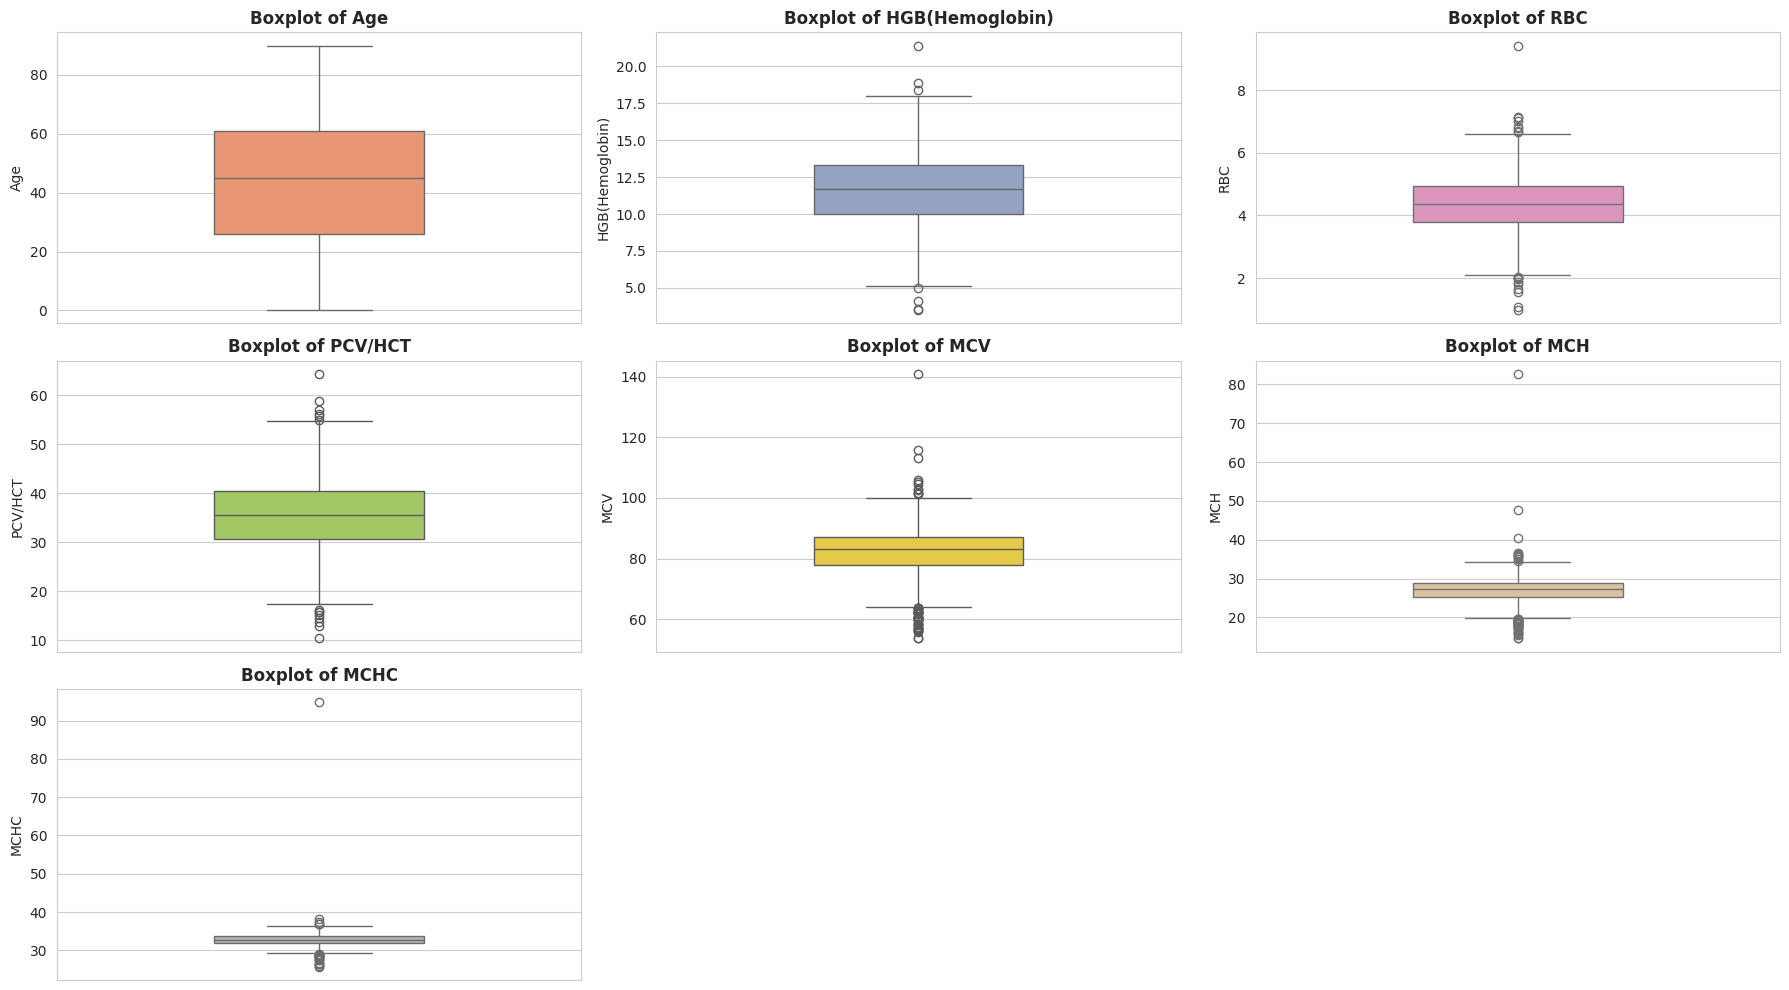


Outlier counts using IQR method:
Age: 0 outliers
HGB(Hemoglobin): 7 outliers
RBC: 18 outliers
PCV/HCT: 14 outliers
MCV: 48 outliers
MCH: 49 outliers
MCHC: 23 outliers

Possible outlier rows in MCHC:
     Gender   Age  HGB(Hemoglobin)   RBC  PCV/HCT   MCV   MCH  MCHC  \
36   Female  15.0              7.5  4.85     27.2  56.1  15.4  27.5   
77   Female  55.0              5.1  3.18     19.3  60.7  16.0  26.4   
104  Female  48.0              9.8  5.14     33.7  65.6  19.1  29.1   
318    Male  60.0              9.8  4.47     34.1  76.3  21.9  28.7   
364    Male  38.0             16.7  9.42     58.8  62.4  17.7  28.4   
391  Female  63.0              5.9  3.39     20.6  60.8  17.4  28.7   
395  Female  28.0             12.7  6.15     44.9  73.0  20.7  28.3   
447    Male  60.0             10.2  4.12     32.1  77.3  21.8  28.3   
465    Male   2.0              6.6  4.06     24.1  59.4  16.3  27.4   
485  Female  58.0              3.6  1.82     12.9  70.9  18.7  26.4   
553  Female  53.0  

In [9]:
# =========================
# Phase 2: Clean the dataset
# Step 3 to Step 6
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy so original dataframe stays unchanged
df_clean = df.copy()

# -------------------------
# Step 3: Fix categorical inconsistencies
# Standardize Gender values
# -------------------------
print("Unique Gender values BEFORE cleaning:")
print(df_clean["Gender"].unique())

# Convert to string, strip spaces, lowercase
df_clean["Gender"] = df_clean["Gender"].astype(str).str.strip().str.lower()

# Standard mapping
gender_map = {
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female"
}

df_clean["Gender"] = df_clean["Gender"].replace(gender_map)

print("\nUnique Gender values AFTER cleaning:")
print(df_clean["Gender"].unique())

print("\nGender value counts AFTER cleaning:")
print(df_clean["Gender"].value_counts(dropna=False))

# Optional: check if any unexpected value still remains
unexpected_gender = df_clean[~df_clean["Gender"].isin(["Male", "Female"])]
print("\nRows with unexpected Gender values:")
print(unexpected_gender)


# -------------------------
# Step 4: Handle missing values
# Fill missing PCV/HCT using median
# -------------------------
print("\nMissing values BEFORE imputation:")
print(df_clean.isnull().sum())

pcv_median = df_clean["PCV/HCT"].median()
df_clean["PCV/HCT"] = df_clean["PCV/HCT"].fillna(pcv_median)

print("\nMedian used for PCV/HCT imputation:", pcv_median)

print("\nMissing values AFTER imputation:")
print(df_clean.isnull().sum())


# -------------------------
# Step 5: Remove exact duplicates
# -------------------------
print("\nShape BEFORE removing duplicates:", df_clean.shape)
print("Duplicate rows BEFORE removal:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("\nShape AFTER removing duplicates:", df_clean.shape)
print("Duplicate rows AFTER removal:", df_clean.duplicated().sum())


# -------------------------
# Step 6: Inspect outliers with colorful boxplots
# -------------------------
numeric_cols = ["Age", "HGB(Hemoglobin)", "RBC", "PCV/HCT", "MCV", "MCH", "MCHC"]

# Summary statistics
print("\nSummary statistics for numeric columns:")
print(df_clean[numeric_cols].describe())

# Boxplots
plt.figure(figsize=(18, 10))
sns.set_style("whitegrid")

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(
        y=df_clean[col],
        color=sns.color_palette("Set2")[i % len(sns.color_palette("Set2"))],
        width=0.4
    )
    plt.title(f"Boxplot of {col}", fontsize=12, fontweight="bold")
    plt.ylabel(col)

plt.tight_layout()
plt.show()


# -------------------------
# Optional: Count outliers using IQR method
# This helps you inspect suspicious values
# -------------------------
print("\nOutlier counts using IQR method:")

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    print(f"{col}: {len(outliers)} outliers")

# -------------------------
# Optional: Show actual suspicious rows for one feature
# Example: MCHC
# -------------------------
col = "MCHC"
Q1 = df_clean[col].quantile(0.25)
Q3 = df_clean[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mchc_outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

print(f"\nPossible outlier rows in {col}:")
print(mchc_outliers)

Dataset shape:
(977, 9)

First 5 rows:
   Gender   Age  HGB(Hemoglobin)   RBC  PCV/HCT   MCV   MCH  MCHC  \
0  Female  45.0             12.1  4.64     37.9  81.7  26.1  31.9   
1    Male  70.0             13.4  5.32     45.8  86.1  25.2  29.3   
2  Female  80.0              8.3  3.04     25.2  82.9  27.3  32.9   
3  Female  30.0             11.1  3.98     33.5  84.2  27.9  33.1   
4  Female  46.0             15.5  5.50     45.7  83.1  28.2  33.9   

   Decision_Class  
0               0  
1               0  
2               1  
3               0  
4               0  

Summary statistics:
        Gender         Age  HGB(Hemoglobin)         RBC     PCV/HCT  \
count      977  977.000000       977.000000  977.000000  977.000000   
unique       2         NaN              NaN         NaN         NaN   
top     Female         NaN              NaN         NaN         NaN   
freq       518         NaN              NaN         NaN         NaN   
mean       NaN   43.737871        11.663951    4.3

/tmp/ipykernel_2519/3426122184.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Decision_Class", palette="Set2")


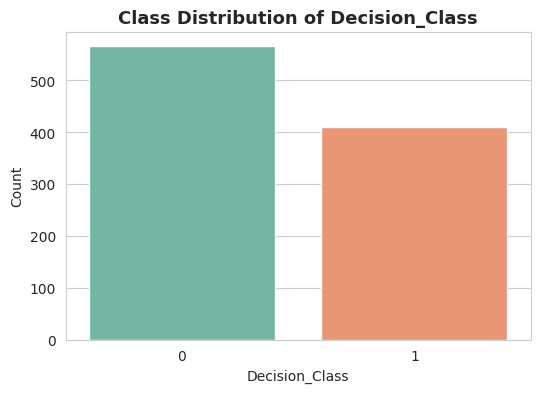

/tmp/ipykernel_2519/3426122184.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Gender", palette="pastel")


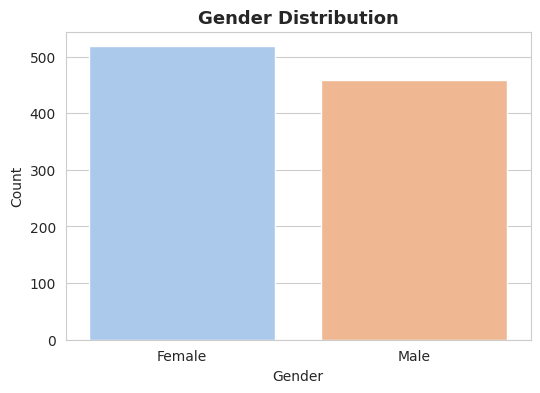

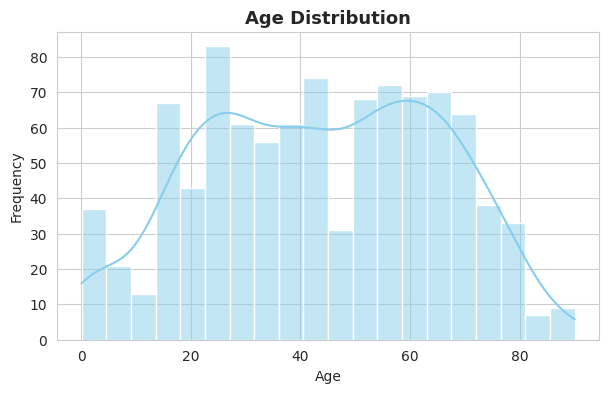

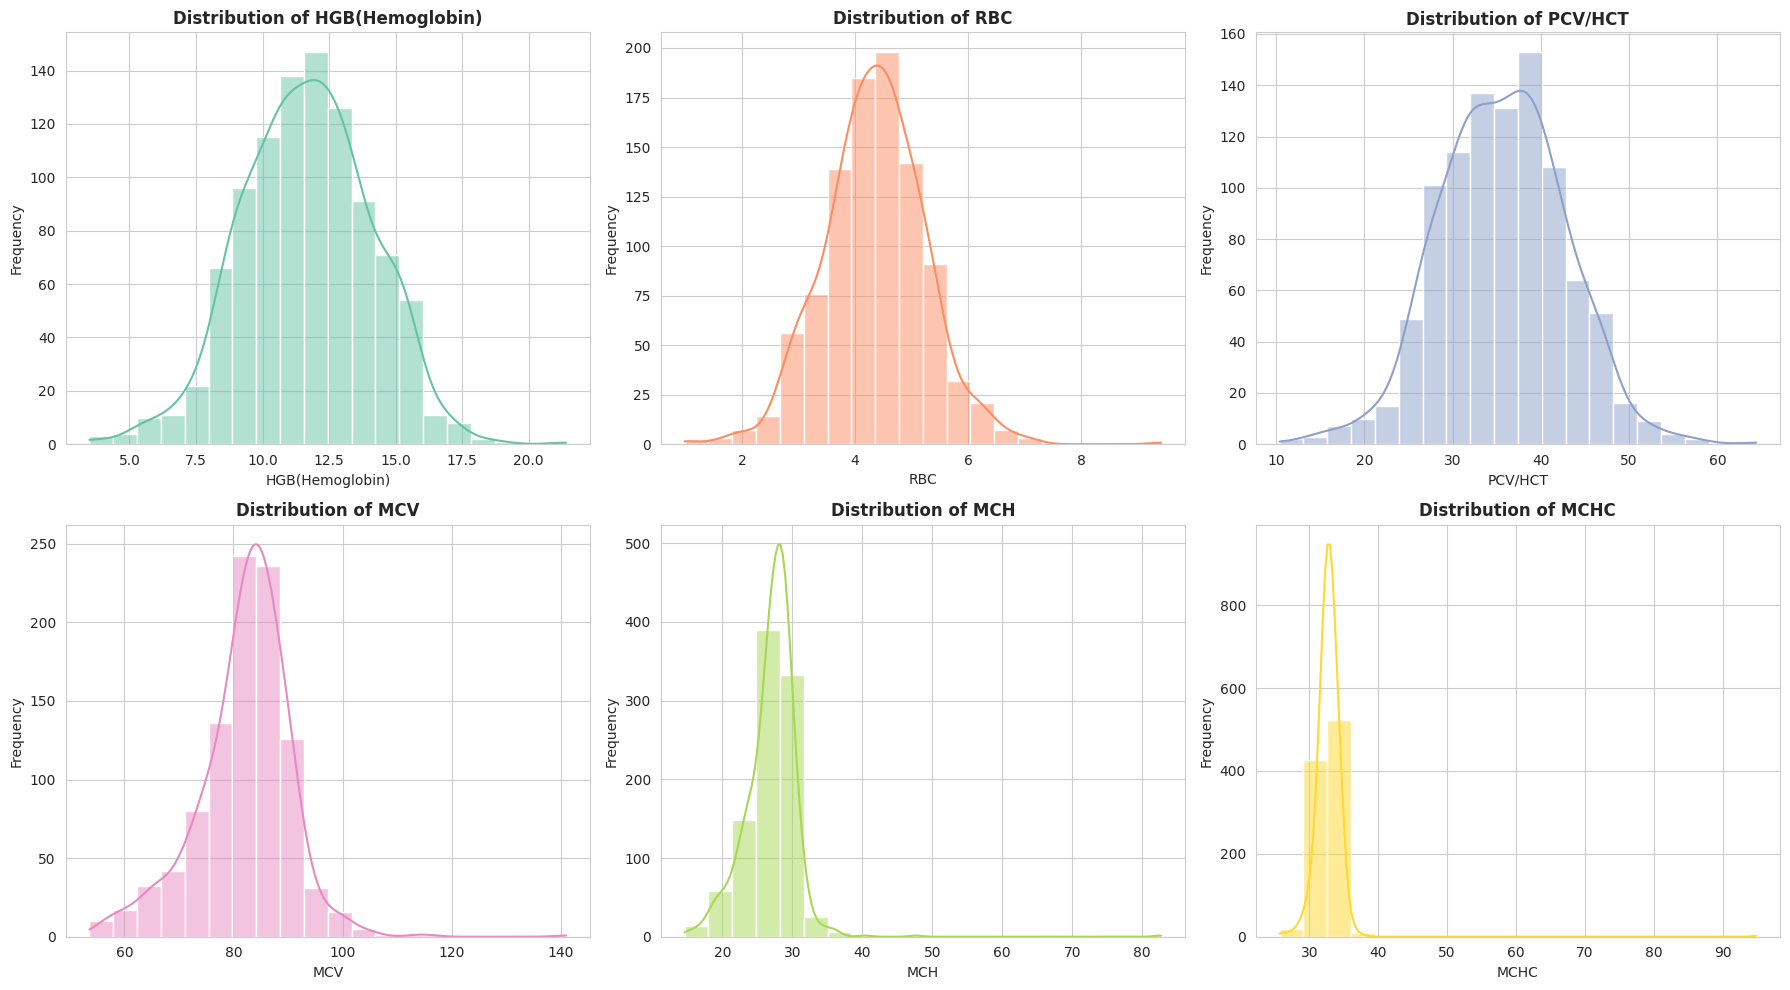

/tmp/ipykernel_2519/3426122184.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Decision_Class", y=col, palette="Set3")
/tmp/ipykernel_2519/3426122184.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Decision_Class", y=col, palette="Set3")
/tmp/ipykernel_2519/3426122184.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Decision_Class", y=col, palette="Set3")
/tmp/ipykernel_2519/3426122184.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will b

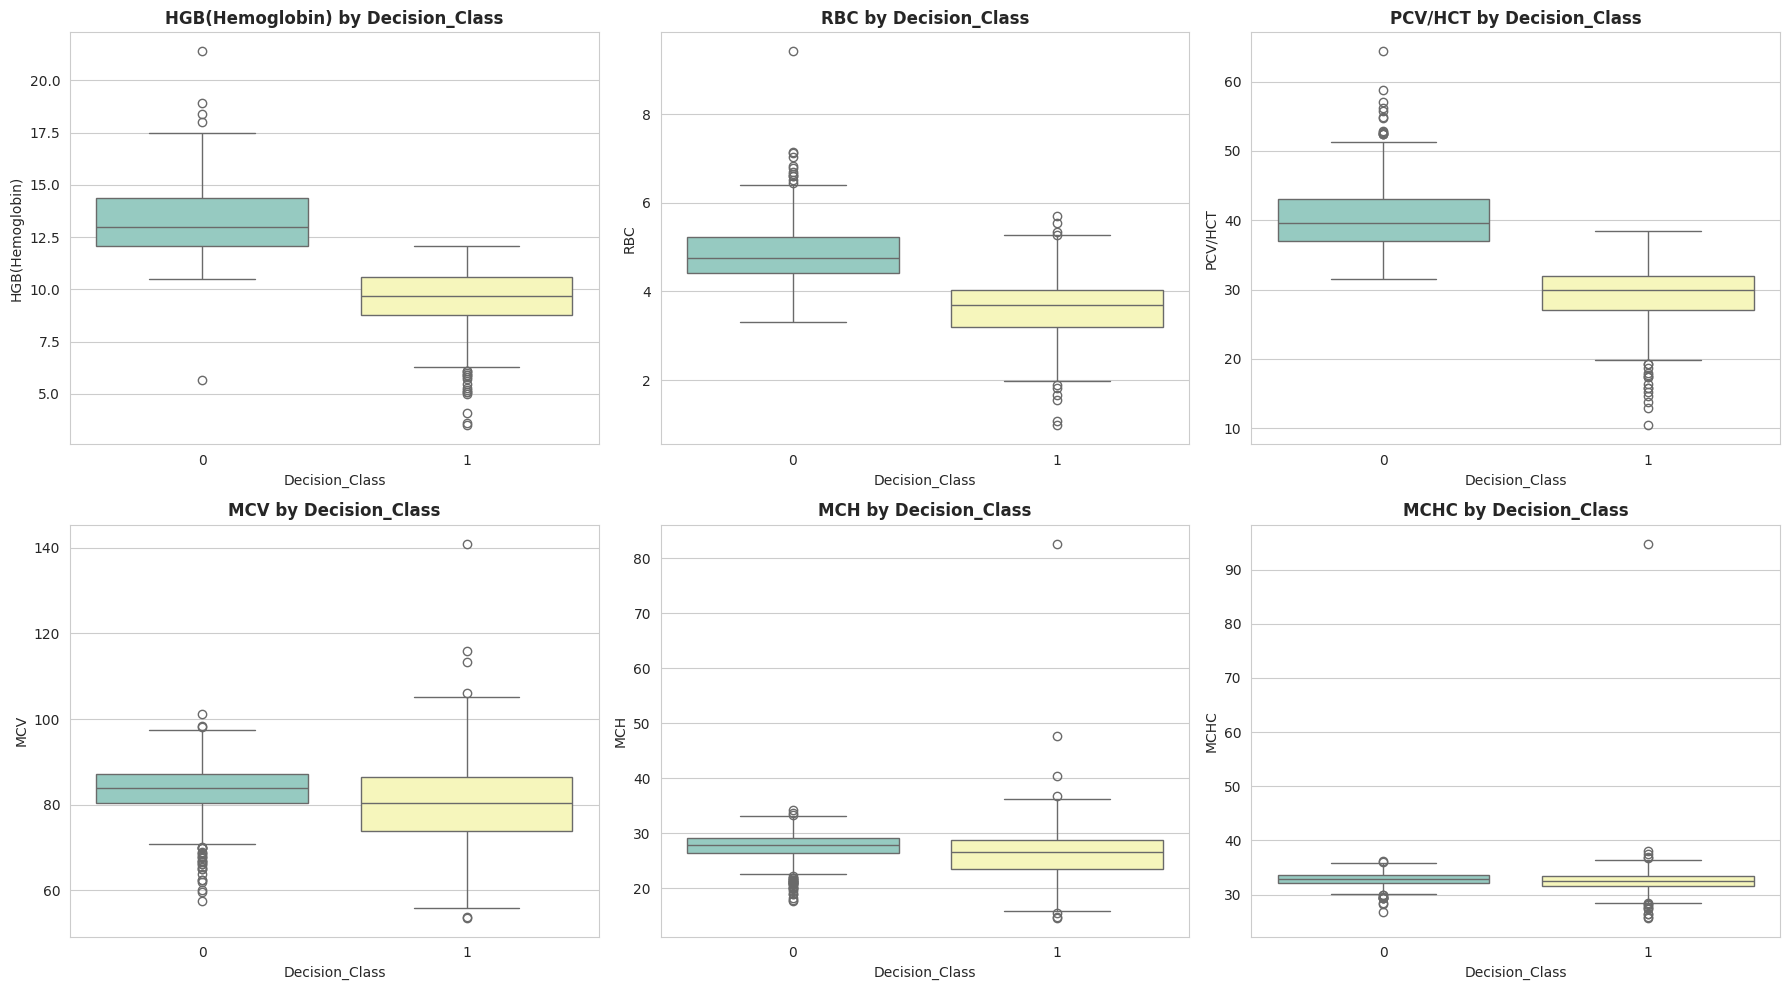

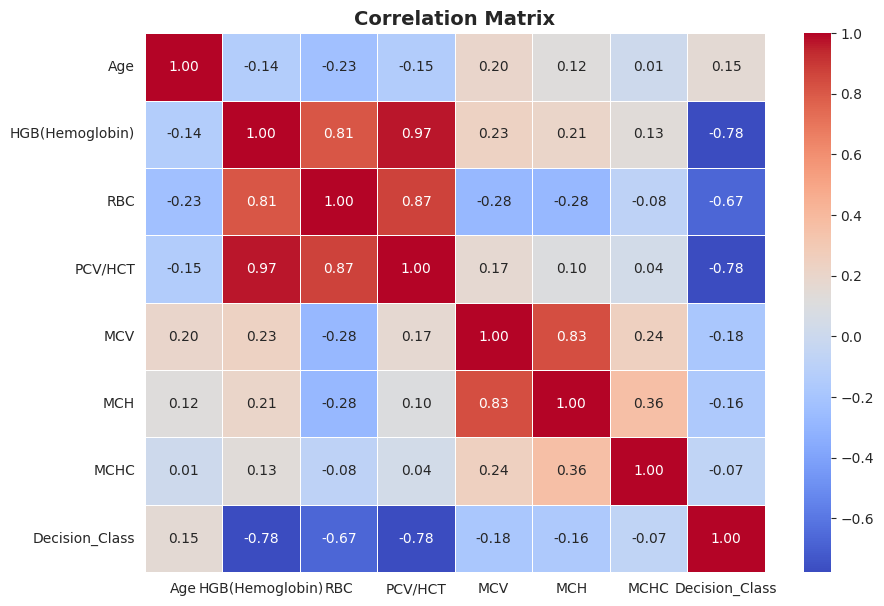

In [10]:
# =========================
# Phase 3: Explore the data
# Step 7: Exploratory Data Analysis
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# -------------------------
# Basic summary
# -------------------------
print("Dataset shape:")
print(df_clean.shape)

print("\nFirst 5 rows:")
print(df_clean.head())

print("\nSummary statistics:")
print(df_clean.describe(include="all"))

print("\nClass distribution:")
print(df_clean["Decision_Class"].value_counts())

print("\nGender distribution:")
print(df_clean["Gender"].value_counts())

# -------------------------
# 1. Class distribution
# -------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="Decision_Class", palette="Set2")
plt.title("Class Distribution of Decision_Class", fontsize=13, fontweight="bold")
plt.xlabel("Decision_Class")
plt.ylabel("Count")
plt.show()

# -------------------------
# 2. Gender distribution
# -------------------------
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="Gender", palette="pastel")
plt.title("Gender Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# -------------------------
# 3. Age distribution
# -------------------------
plt.figure(figsize=(7, 4))
sns.histplot(data=df_clean, x="Age", bins=20, kde=True, color="skyblue")
plt.title("Age Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# -------------------------
# 4. Histograms of blood features
# -------------------------
blood_features = ["HGB(Hemoglobin)", "RBC", "PCV/HCT", "MCV", "MCH", "MCHC"]

plt.figure(figsize=(18, 10))

for i, col in enumerate(blood_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df_clean[col], bins=20, kde=True, color=sns.color_palette("Set2")[i-1])
    plt.title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# -------------------------
# 5. Boxplots by anemia class
# -------------------------
plt.figure(figsize=(18, 10))

for i, col in enumerate(blood_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df_clean, x="Decision_Class", y=col, palette="Set3")
    plt.title(f"{col} by Decision_Class", fontsize=12, fontweight="bold")
    plt.xlabel("Decision_Class")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# -------------------------
# 6. Correlation matrix
# -------------------------
numeric_cols = ["Age", "HGB(Hemoglobin)", "RBC", "PCV/HCT", "MCV", "MCH", "MCHC", "Decision_Class"]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

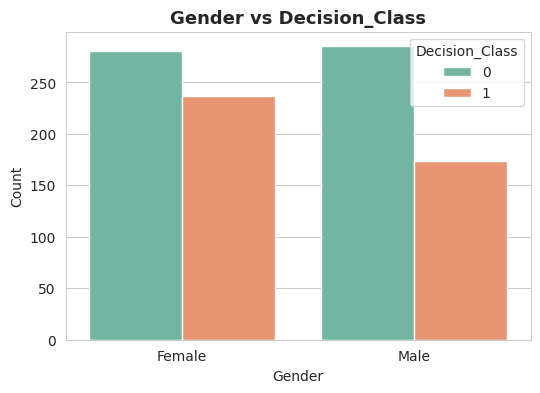

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="Gender", hue="Decision_Class", palette="Set2")
plt.title("Gender vs Decision_Class", fontsize=13, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

/tmp/ipykernel_2519/2222737478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Decision_Class", y="Age", palette="pastel")


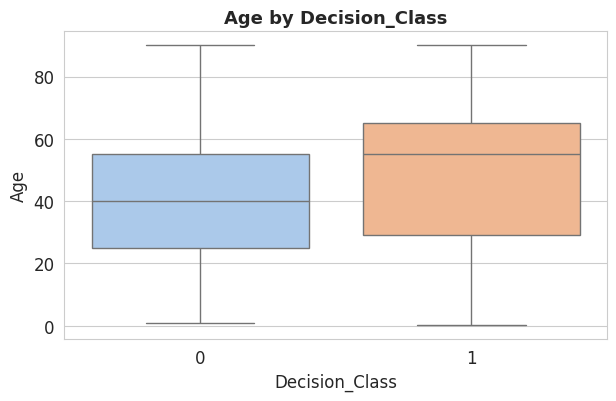

In [15]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df_clean, x="Decision_Class", y="Age", palette="pastel")
plt.title("Age by Decision_Class", fontsize=13, fontweight="bold")
plt.xlabel("Decision_Class")
plt.ylabel("Age")
plt.show()

In [16]:
# =========================
# Step 8: Basic statistical comparison
# Compare anemia vs non-anemia groups
# =========================

import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency

# Split data into two groups
anemia_df = df_clean[df_clean["Decision_Class"] == 1]
non_anemia_df = df_clean[df_clean["Decision_Class"] == 0]

print("Anemia group shape:", anemia_df.shape)
print("Non-anemia group shape:", non_anemia_df.shape)

# -------------------------
# 1. Numeric feature comparison using t-test
# -------------------------
numeric_features = ["Age", "HGB(Hemoglobin)", "RBC", "PCV/HCT", "MCV", "MCH", "MCHC"]

results = []

for col in numeric_features:
    anemia_mean = anemia_df[col].mean()
    anemia_std = anemia_df[col].std()

    non_anemia_mean = non_anemia_df[col].mean()
    non_anemia_std = non_anemia_df[col].std()

    # Welch's t-test is safer when variance may differ
    t_stat, p_value = ttest_ind(
        anemia_df[col],
        non_anemia_df[col],
        equal_var=False,
        nan_policy="omit"
    )

    results.append({
        "Feature": col,
        "Anemia_Mean": round(anemia_mean, 3),
        "Anemia_SD": round(anemia_std, 3),
        "Non_Anemia_Mean": round(non_anemia_mean, 3),
        "Non_Anemia_SD": round(non_anemia_std, 3),
        "T_Statistic": round(t_stat, 3),
        "P_Value": round(p_value, 6),
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

stat_results_df = pd.DataFrame(results)

print("\nStatistical comparison for numeric features")
print(stat_results_df)

Anemia group shape: (411, 10)
Non-anemia group shape: (566, 10)

Statistical comparison for numeric features
           Feature  Anemia_Mean  Anemia_SD  Non_Anemia_Mean  Non_Anemia_SD  \
0              Age       47.605     23.682           40.930         19.275   
1  HGB(Hemoglobin)        9.455      1.437           13.268          1.592   
2              RBC        3.640      0.679            4.863          0.653   
3          PCV/HCT       29.083      4.235           40.344          4.678   
4              MCV       80.171     10.791           83.371          6.212   
5              MCH       26.241      4.994           27.489          2.488   
6             MCHC       32.590      3.537           32.936          1.198   

   T_Statistic   P_Value Significant  
0        4.695  0.000003         Yes  
1      -39.115  0.000000         Yes  
2      -28.261  0.000000         Yes  
3      -39.254  0.000000         Yes  
4       -5.398  0.000000         Yes  
5       -4.662  0.000004        

In [17]:
# -------------------------
# 2. Gender comparison using chi-square test
# -------------------------

gender_table = pd.crosstab(df_clean["Gender"], df_clean["Decision_Class"])

print("\nContingency table for Gender vs Decision_Class")
print(gender_table)

chi2, p_value, dof, expected = chi2_contingency(gender_table)

print("\nChi-square test result for Gender vs Decision_Class")
print("Chi-square statistic:", round(chi2, 3))
print("P-value:", round(p_value, 6))
print("Degrees of freedom:", dof)
print("Significant association:", "Yes" if p_value < 0.05 else "No")


Contingency table for Gender vs Decision_Class
Decision_Class    0    1
Gender                  
Female          281  237
Male            285  174

Chi-square test result for Gender vs Decision_Class
Chi-square statistic: 5.827
P-value: 0.015782
Degrees of freedom: 1
Significant association: Yes


In [18]:
stat_results_df = stat_results_df.sort_values(by="P_Value").reset_index(drop=True)

print("\nNumeric features sorted by p-value")
print(stat_results_df)


Numeric features sorted by p-value
           Feature  Anemia_Mean  Anemia_SD  Non_Anemia_Mean  Non_Anemia_SD  \
0  HGB(Hemoglobin)        9.455      1.437           13.268          1.592   
1              RBC        3.640      0.679            4.863          0.653   
2          PCV/HCT       29.083      4.235           40.344          4.678   
3              MCV       80.171     10.791           83.371          6.212   
4              Age       47.605     23.682           40.930         19.275   
5              MCH       26.241      4.994           27.489          2.488   
6             MCHC       32.590      3.537           32.936          1.198   

   T_Statistic   P_Value Significant  
0      -39.115  0.000000         Yes  
1      -28.261  0.000000         Yes  
2      -39.254  0.000000         Yes  
3       -5.398  0.000000         Yes  
4        4.695  0.000003         Yes  
5       -4.662  0.000004         Yes  
6       -1.908  0.057044          No  


In [19]:
stat_results_df.to_csv("statistical_comparison_results.csv", index=False)
print("\nSaved: statistical_comparison_results.csv")


Saved: statistical_comparison_results.csv


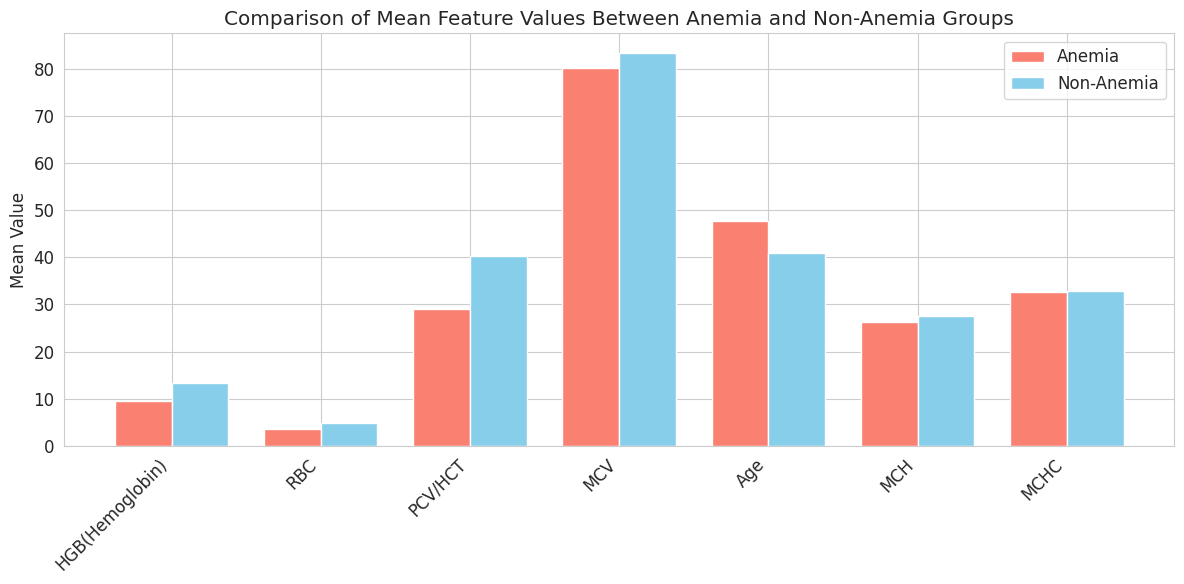

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Make sure Feature is used as index
plot_df = stat_results_df.copy()

features = plot_df["Feature"]
anemia_means = plot_df["Anemia_Mean"]
non_anemia_means = plot_df["Non_Anemia_Mean"]

x = np.arange(len(features))
width = 0.38

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, anemia_means, width, label="Anemia", color="salmon")
plt.bar(x + width/2, non_anemia_means, width, label="Non-Anemia", color="skyblue")

plt.xticks(x, features, rotation=45, ha="right")
plt.ylabel("Mean Value")
plt.title("Comparison of Mean Feature Values Between Anemia and Non-Anemia Groups")
plt.legend()
plt.tight_layout()
plt.show()

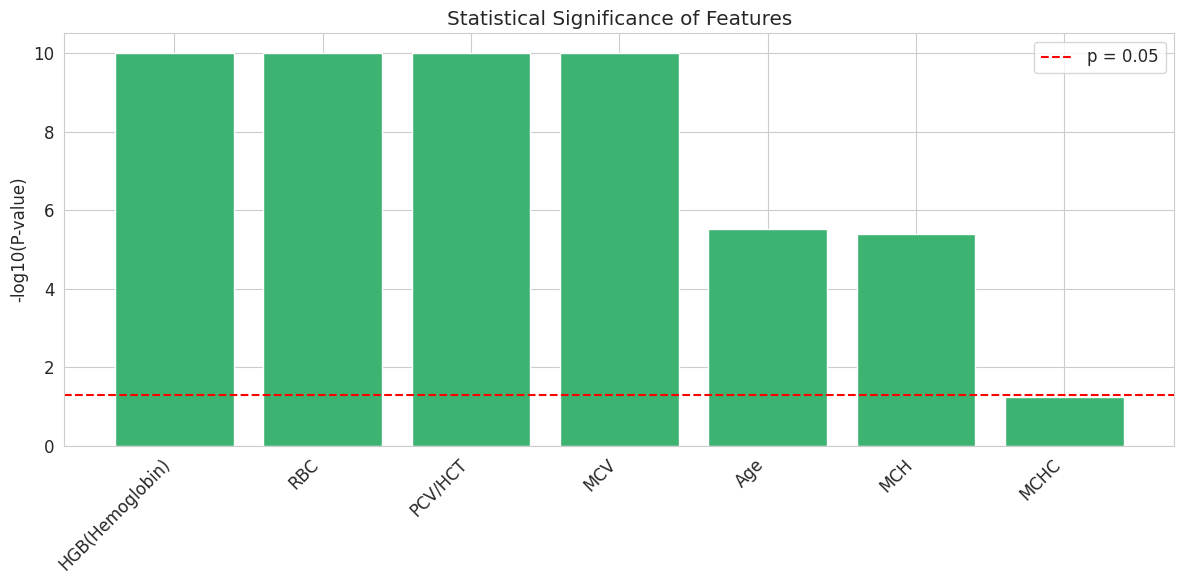

In [21]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = stat_results_df.copy()

# Avoid log problems if p-value is extremely small
plot_df["P_Value_Adjusted"] = plot_df["P_Value"].replace(0, 1e-10)
plot_df["Minus_Log10_P"] = -np.log10(plot_df["P_Value_Adjusted"])

plt.figure(figsize=(12, 6))
bars = plt.bar(plot_df["Feature"], plot_df["Minus_Log10_P"], color="mediumseagreen")

# significance threshold line for p = 0.05
threshold = -np.log10(0.05)
plt.axhline(y=threshold, color="red", linestyle="--", label="p = 0.05")

plt.xticks(rotation=45, ha="right")
plt.ylabel("-log10(P-value)")
plt.title("Statistical Significance of Features")
plt.legend()
plt.tight_layout()
plt.show()

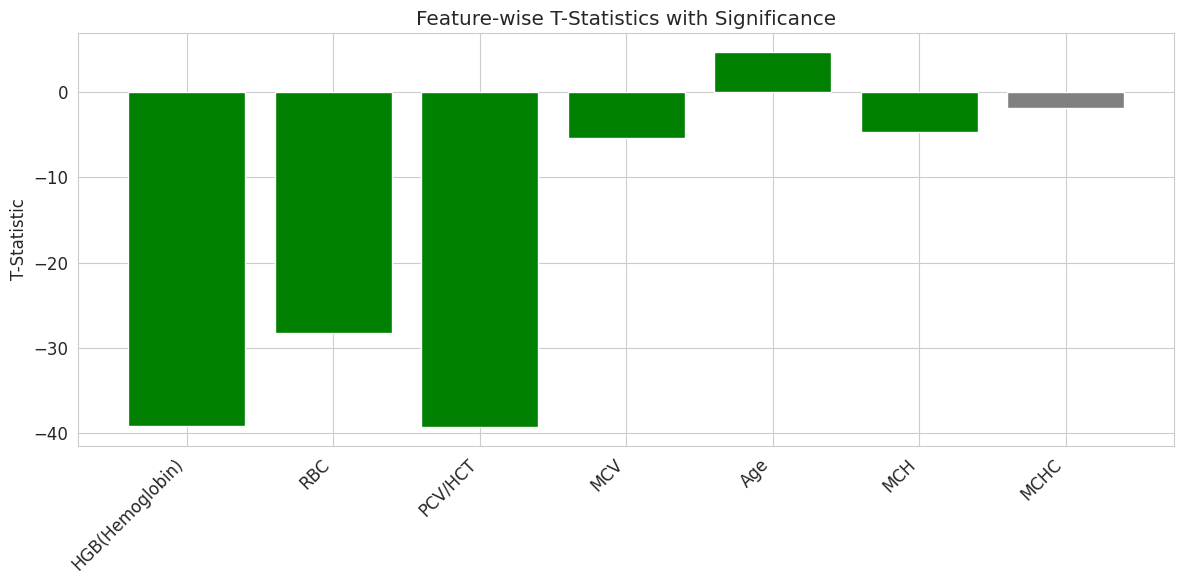

In [22]:
import matplotlib.pyplot as plt

plot_df = stat_results_df.copy()
colors = ["green" if x == "Yes" else "gray" for x in plot_df["Significant"]]

plt.figure(figsize=(12, 6))
plt.bar(plot_df["Feature"], plot_df["T_Statistic"], color=colors)

plt.xticks(rotation=45, ha="right")
plt.ylabel("T-Statistic")
plt.title("Feature-wise T-Statistics with Significance")
plt.tight_layout()
plt.show()


Logistic Regression Performance
        Metric   Value
0     Accuracy  0.9796
1    Precision  0.9756
2       Recall  0.9756
3     F1-score  0.9756
4  Specificity  0.9825
5      ROC-AUC  0.9929
6       PR-AUC  0.9932


<Figure size 500x400 with 0 Axes>

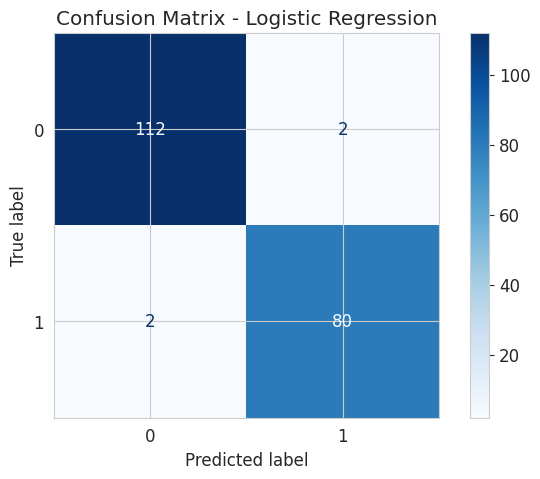

TN = 112
FP = 2
FN = 2
TP = 80


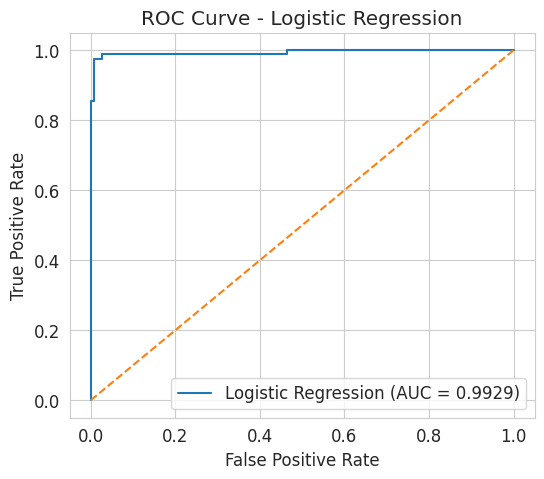

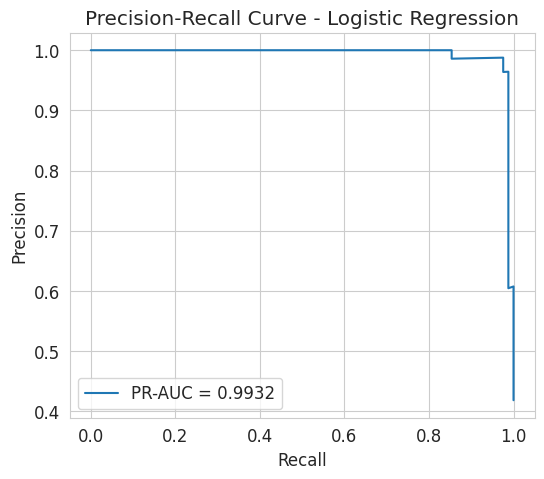

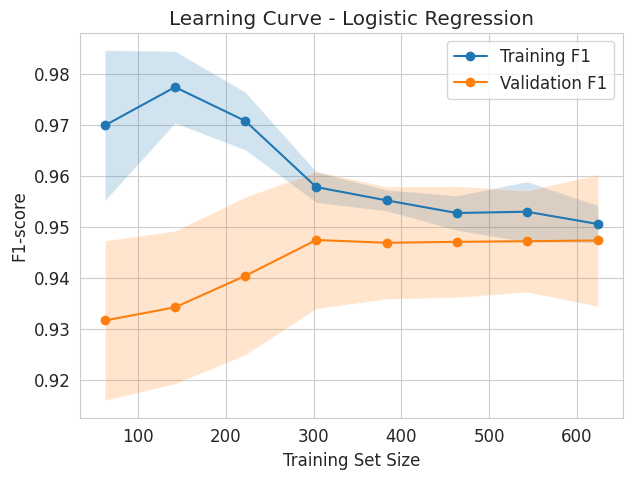

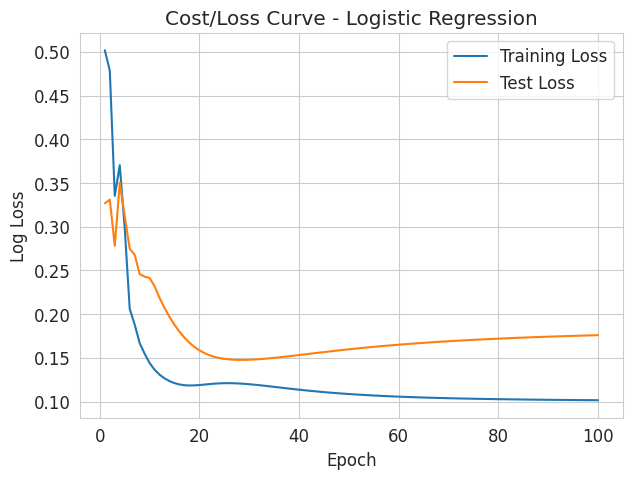

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    log_loss
)

# 1. X and y
target_column = "Decision_Class"
# Exclude 'Class_Label' as it's a target-derived label and not a feature
X = df_clean.drop(columns=[target_column, 'Class_Label'])
y = df_clean[target_column]

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 3. Preprocessing
categorical_features = [col for col in X_train.columns if X_train[col].dtype == 'object']
numeric_features = [col for col in X_train.columns if X_train[col].dtype != 'object']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# 4. Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# 5. Train
logreg_pipeline.fit(X_train, y_train)

# 6. Predict
y_pred = logreg_pipeline.predict(X_test)
y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

# 7. Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy", "Precision", "Recall", "F1-score",
        "Specificity", "ROC-AUC", "PR-AUC"
    ],
    "Value": [acc, prec, rec, f1, specificity, roc_auc, pr_auc]
}).round(4)

print("\nLogistic Regression Performance")
print(metrics_df)

# 8. Confusion Matrix
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

# 9. ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# 10. PR curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# 11. Learning curve
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    estimator=logreg_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Training F1")
plt.plot(train_sizes, val_mean, marker="o", label="Validation F1")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.xlabel("Training Set Size")
plt.ylabel("F1-score")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# 12. Cost/Loss curve using SGD logistic regression
X_train_processed = logreg_pipeline.named_steps["preprocessor"].transform(X_train)
X_test_processed = logreg_pipeline.named_steps["preprocessor"].transform(X_test)

if hasattr(X_train_processed, "toarray"):
    X_train_processed_dense = X_train_processed.toarray()
    X_test_processed_dense = X_test_processed.toarray()
else:
    X_train_processed_dense = X_train_processed
    X_test_processed_dense = X_test_processed

sgd_logreg = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.0001,
    max_iter=1,
    learning_rate="optimal",
    random_state=42,
    warm_start=True
)

epochs = 100
train_loss_history = []
test_loss_history = []
classes = np.unique(y_train)

for epoch in range(epochs):
    sgd_logreg.partial_fit(X_train_processed_dense, y_train, classes=classes)
    train_prob_epoch = sgd_logreg.predict_proba(X_train_processed_dense)
    test_prob_epoch = sgd_logreg.predict_proba(X_test_processed_dense)

    train_loss_history.append(log_loss(y_train, train_prob_epoch))
    test_loss_history.append(log_loss(y_test, test_prob_epoch))

plt.figure(figsize=(7, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label="Training Loss")
plt.plot(range(1, epochs + 1), test_loss_history, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Cost/Loss Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

Early stopping triggered at epoch 6. Best epoch was 1


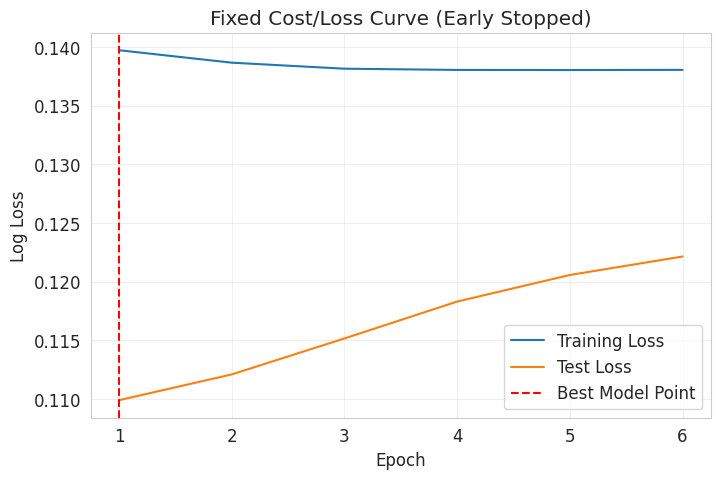


Final Logistic Regression Performance Metrics:
Accuracy:  0.9796
F1-Score:  0.9759
ROC-AUC:   0.9933


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve, log_loss
)

# --- 1. Data Setup (Assuming df_clean exists) ---
target_column = "Decision_Class"
X = df_clean.drop(columns=[target_column, 'Class_Label'])
y = df_clean[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# --- 2. Preprocessing Pipeline ---
categorical_features = [col for col in X_train.columns if X_train[col].dtype == 'object']
numeric_features = [col for col in X_train.columns if X_train[col].dtype != 'object']

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# --- 3. Training the Final Logistic Regression Model ---
# We use liblinear here for the final "production" metrics
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        C=0.1  # Added stronger regularization (smaller C) to fix the gap
    ))
])

logreg_pipeline.fit(X_train, y_train)

# --- 4. Diagnostics: Cost/Loss Curve with Early Stopping ---
# To see the loss per epoch, we use SGDClassifier
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

# Convert to dense if the encoder produced a sparse matrix
X_train_dense = X_train_proc.toarray() if hasattr(X_train_proc, "toarray") else X_train_proc
X_test_dense = X_test_proc.toarray() if hasattr(X_test_proc, "toarray") else X_test_proc

sgd_logreg = SGDClassifier(
    loss="log_loss",
    penalty="l2",
    alpha=0.01,  # Increased regularization to prevent overfitting
    learning_rate="optimal",
    random_state=42,
    warm_start=True
)

epochs = 100
train_loss_history = []
test_loss_history = []
classes = np.unique(y_train)

# Early Stopping parameters
best_loss = np.inf
patience = 5
wait = 0
best_epoch = 0

for epoch in range(epochs):
    sgd_logreg.partial_fit(X_train_dense, y_train, classes=classes)

    tr_loss = log_loss(y_train, sgd_logreg.predict_proba(X_train_dense))
    te_loss = log_loss(y_test, sgd_logreg.predict_proba(X_test_dense))

    train_loss_history.append(tr_loss)
    test_loss_history.append(te_loss)

    # Check if test loss improved
    if te_loss < best_loss:
        best_loss = te_loss
        best_epoch = epoch
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}. Best epoch was {best_epoch+1}")
            break

# --- 5. Visualization: Improved Cost/Loss Curve ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_loss_history) + 1), train_loss_history, label="Training Loss")
plt.plot(range(1, len(test_loss_history) + 1), test_loss_history, label="Test Loss")
plt.axvline(x=best_epoch + 1, color='red', linestyle='--', label='Best Model Point')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Fixed Cost/Loss Curve (Early Stopped)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 6. Final Performance Metrics (using the main pipeline) ---
y_pred = logreg_pipeline.predict(X_test)
y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

print("\nFinal Logistic Regression Performance Metrics:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")